# RMSD dataset

In [32]:
import numpy as np
from pyemma import msm, plots
import matplotlib.pyplot as plt
import itertools

import pandas as pd
state_info = pd.read_csv('../data/rama_state_index.txt',sep='\s+')
def nearest_state(df, target):
    df['distance'] = (df['phi'] - target[0])**2 + (df['psi'] - target[1])**2
    state = df.sort_values(by='distance')['state']
    return state
def load_data(path):
    data = np.loadtxt(path, dtype= int)
    # data = Rm_peaks_steps(data, 100)
    return data

In [4]:
# for lstm experiment
task = 'RMSD' 
# task = 'MacroAssignment'
datapath = f'../data/{task}/train'
train=np.loadtxt(datapath, dtype=int).reshape(-1)
test = np.loadtxt(f'../data/{task}/test', dtype=int).reshape(-1)

## load GPT LSTM data

In [4]:

interval=2
lag_limit = 200 
lag_times=range(int(10/(interval*0.1)),int(lag_limit/(interval*0.1)),int(10/(interval*0.1)))

train_interval = train.reshape(-1, interval).T.flatten()
train_interval_ts = msm.its(train_interval, lag_times, nits=3, show_progress=False)


In [5]:
lr = 0.0001 if interval==2 else 0.001
pred_path = '/home/wzengad/projects/MD_code/LSTM/results/RMSD/trans_gpt/Label0.0_window50_interval2_lr0.0005_emb_dim128_l100_block3_scheduled/category/epoch80_100000_valid_interval2'
# pred_path = f'/home/wzengad/projects/MD_code/LSTM/results/RMSD/trans_gpt/Label0.0_window50_interval{interval}_lr0.0001_emb_dim128_l100_block3_scheduled/category/epoch280_100000_valid_interval{interval}'
# pred_path = f'/home/wzengad/projects/MD_code/LSTM/results/RMSD/trans_gpt/Label0.0_window50_interval{interval}_lr{lr}_l100_block3_no_pos_scheduled/category/epoch280_100000_valid_interval{interval}'
pred_traj = [load_data(pred_path + f'/no_gen_pos_prediction_{i}') for i in range(20)]


In [ ]:
lstm_path = f'/home/wzengad/projects/MD_code/LSTM/results/RMSD/lstm/Label0.0_sparse50_interval{interval}_lr0.001_l100_units512_emb128_no_pos/category/epoch180_100000_valid_interval{interval}'
pred_lstm = [load_data(lstm_path + f'/no_gen_pos_prediction_{i}') for i in range(20)]
pred_lstm = msm.its(pred_lstm, lag_times, nits=3, show_progress=False)
pred_lstm.timescales*interval

In [31]:
# lr = 0.0001 if interval==2 else 0.001
# for ITS
pred_path = '../results/RMSD/trans_gpt/Label0.0_window50_interval2_lr0.0005_emb_dim128_l100_block1_scheduled/category/epoch280_100000_valid_interval2'
# pred_path = '../results/RMSD/trans_gpt/category/epoch280_100000_valid_interval2'
pred_traj = [load_data(pred_path + f'/no_gen_pos_prediction_{i}') for i in range(20)]

# pred_traj = load_data(pred_path + f'/no_gen_pos_prediction_5')
pred_gpt = msm.its(pred_traj, lag_times, nits=3, show_progress=False)
pred_gpt.timescales*interval


NameError: name 'load_data' is not defined

In [9]:
import matplotlib.style as style 
import matplotlib
style.available

style.use('seaborn-paper') #sets the size of the charts
# style.use('ggplot')

matplotlib.rcParams['font.family'] = "serif"

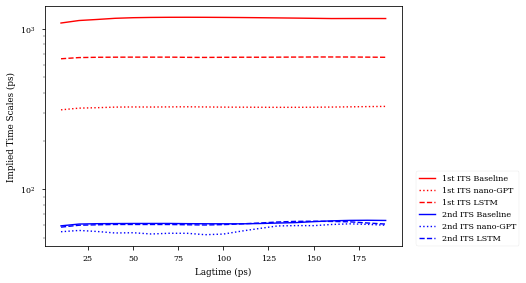

In [21]:
marker = itertools.cycle(('o', 'v', '^', '<', '>', 's', '8', 'p'))
baseline = train_interval_ts.timescales*interval*0.1
gpt = pred_gpt.timescales*interval*0.1
lstm = pred_lstm.timescales*interval*0.1
lag_times_x = np.array(lag_times)*interval*0.1

plt.plot(lag_times_x, baseline[:,0],'r', label='1st ITS Baseline')
plt.plot(lag_times_x, gpt[:,0], 'r:',label='1st ITS nano-GPT')
plt.plot(lag_times_x, lstm[:,0], 'r--',label='1st ITS LSTM')

plt.plot(lag_times_x, baseline[:,1],'b', label='2nd ITS Baseline')
plt.plot(lag_times_x, gpt[:,1], 'b:',label='2nd ITS nano-GPT')
plt.plot(lag_times_x, lstm[:,1], 'b--',label='2nd ITS LSTM')

# plt.plot(lag_times_x, baseline[:,2],'g', label='3rd ITS Baseline')
# plt.plot(lag_times_x, gpt[:,2], 'g:',label='3rd ITS nano-GPT')
# plt.plot(lag_times_x, lstm[:,2], 'g--',label='3rd ITS LSTM')

plt.legend(loc=(1.04, 0))
plt.ylabel('Implied Time Scales (ps)')
plt.yscale("log")
plt.xlabel('Lagtime (ps)')
plt.show()
# plt.savefig(f'/home/wzengad/projects/MD_code/Fig/ITS_{interval}.pdf', format='pdf',bbox_inches='tight', dpi=600, pad_inches = 0.05)

In [ ]:
transition = ['AB','BA','AC','CA','AD','DA','BC','CB','BD','DB','CD','DC']
plots = [4,5,6,7]
import matplotlib.style as style 
import matplotlib
style.available
style.use('seaborn-paper') #sets the size of the charts
# style.use('ggplot')
# style.use('_mpl-gallery')
matplotlib.rcParams['font.family'] = "serif"

for plot_choice in plots:
 

    g_plot = np.loadtxt(f'/home/wzengad/projects/MD_code/Fig_data/transition_count/g_plot',dtype=int)
    l_plot = np.loadtxt(f'/home/wzengad/projects/MD_code/Fig_data/transition_count/l_plot',dtype=int)
    M_plot = np.loadtxt(f'/home/wzengad/projects/MD_code/Fig_data/transition_count/m_plot',dtype=int)

    fig, ax = plt.subplots(figsize=(12,4)) 
    ax.scatter(np.arange(len(M_plot)), M_plot, s=80, marker='s', facecolor='none', edgecolor='r', c='darkorange', label= 'Baseline')
    ax.errorbar(np.arange(len(M_plot)), g_plot.mean(axis=0), yerr=g_plot.std(axis=0), fmt='o', c='mediumblue',  markersize=5, capsize=10, label='nano-GPT')
    ax.errorbar(np.arange(len(M_plot)), l_plot.mean(axis=0), yerr=l_plot.std(axis=0), fmt='o',   c='darkgreen', markersize=5, capsize=10, label='LSTM')

    ax.tick_params(axis='both', which='both', direction='in', labelsize=16)
    ax.set_xlabel('Commit Time', size=16)
    ax.set_ylabel('Count', size=16)
    # x=np.arange(len(M_plot))
    # x = [0,5,10,15,20,25]
    # ax.set_xticks(x, [str(i*50) for i in x])
    ax.xaxis.set_major_locator(plt.MaxNLocator(4))
    # ax.set_xtickslabels([str(i*50) for i in x])
    # ax.set_ylim(-0.2, 30)
    ax.legend(loc='center right', fontsize=16)

    fig.tight_layout()
    plt.savefig(f'/home/wzengad/projects/MD_code/Fig/adjacent_count/{transition[plot_choice]}.pdf', format='pdf', dpi=600, pad_inches = 0.05)


## MFPT

In [5]:
alpha_l = (50, 30)
alpha_r = (-70, -20)
beta = (-130,170)
c5 = (-90, 170)
c7eq = (-80,70)
c7ax = (70,-50)

alpha_l_state = nearest_state(state_info, alpha_l).iloc[0]
alpha_r_state = nearest_state(state_info, alpha_r).iloc[0]
beta_state = nearest_state(state_info, beta).iloc[0]
c5_state= nearest_state(state_info, c5).iloc[0]
c7eq_state = nearest_state(state_info, c7eq).iloc[0]
c7ax_state = nearest_state(state_info, c7ax).iloc[0]

In [6]:
fast1 = (-170, -170)
fast2 = (-50, -170)
fast1_state = nearest_state(state_info, fast1).iloc[0]
fast2_state = nearest_state(state_info, fast2).iloc[0]


In [ ]:
from pyemma import msm
msm_nrev = msm.estimate_markov_model(train, 100)


In [10]:
# lagtime = 10ps, 100*0.1ps
msm_nrev = msm.estimate_markov_model(train, 100)
print(f'alpha_l to alpha_r: generated trajectory: {msm_nrev.mfpt(alpha_l_state,alpha_r_state)}')
print(f'reverse: generated trajectory: {msm_nrev.mfpt(alpha_r_state,alpha_l_state)}')

print(f"fast1 to fast2", msm_nrev.mfpt(fast1_state, fast2_state))
print("reverse", msm_nrev.mfpt(fast2_state, fast1_state))

alpha_l to alpha_r: generated trajectory: 15043.866527973008
reverse: generated trajectory: 849212.3192884345
fast1 to fast2 102634.77741558322
reverse 18482.735068972546


In [27]:
msm_nrev = msm.estimate_markov_model(train, 1)
print(f'alpha_l to alpha_r: generated trajectory: {msm_nrev.mfpt(alpha_l_state,alpha_r_state)}')
print(f'reverse: generated trajectory: {msm_nrev.mfpt(alpha_r_state,alpha_l_state)}')

print(f"fast1 to fast2", msm_nrev.mfpt(fast1_state, fast2_state))
print("reverse", msm_nrev.mfpt(fast2_state, fast1_state)) # should be of ITS of 1~2 ps

alpha_l to alpha_r: generated trajectory: 2382.3416616327377
reverse: generated trajectory: 71204.90551716236
fast1 to fast2 1144.8141392982477
reverse 257.56150255667853


In [20]:
def calculate_mfpt_single(sequence, source_state, target_state):
    """
    Calculate MFPT from source_state to target_state.
    Returns np.inf if no transition is found.
    """
    sequence = np.array(sequence)
    
    # Get positions of source and target states
    source_positions = np.where(sequence == source_state)[0]
    target_positions = np.where(sequence == target_state)[0]
    
    if len(source_positions) == 0 or len(target_positions) == 0:
        return np.inf
        
    # Calculate passage times
    passage_times = []
    for pos in source_positions:
        # Find the first target state that occurs after this position
        future_targets = target_positions[target_positions > pos]
        if len(future_targets) > 0:
            passage_times.append(future_targets[0] - pos)
    
    return np.mean(passage_times) if passage_times else np.inf


In [71]:
# Example usage:
print(calculate_mfpt_single(train, source_state=fast1_state, target_state=fast2_state))
print(calculate_mfpt_single(train, source_state=fast2_state, target_state=fast1_state))
print(calculate_mfpt_single(train, alpha_l_state,alpha_r_state))
print(calculate_mfpt_single(train, alpha_r_state,alpha_l_state))

1294.550841005053
341.74435608004103
17110.36960882648
505743.09366141615


In [72]:
print(calculate_mfpt_single(test, source_state=fast1_state, target_state=fast2_state))
print(calculate_mfpt_single(test, source_state=fast2_state, target_state=fast1_state))
print(calculate_mfpt_single(test, alpha_l_state,alpha_r_state))
print(calculate_mfpt_single(test, alpha_r_state,alpha_l_state))

1290.9978310071672
370.98451213216316
9026.938321536905
157965.18235449836


In [73]:
# pred_path = '../results/RMSD/trans_gpt/epoch280_100000_valid_interval2'
# Label0.0_window50_interval1_lr0.001_l100_block2_no_pos_scheduled
pred_path = '../results/RMSD/trans_gpt/Label0.0_window50_interval1_lr0.001_l100_block2_no_pos_scheduled/category/epoch280_100000_valid_interval1'
pred_traj = [load_data(pred_path + f'/no_gen_pos_prediction_{i}') for i in range(20)]
# pred_traj = np.concatenate(pred_traj)

In [74]:
# for i in range(len(pred_traj)):    
pred_traj_concate = np.concatenate(pred_traj)
print(calculate_mfpt_single(pred_traj_concate, source_state=fast1_state, target_state=fast2_state))
print(calculate_mfpt_single(pred_traj_concate, source_state=fast2_state, target_state=fast1_state))
print(calculate_mfpt_single(pred_traj_concate, alpha_l_state,alpha_r_state))
print(calculate_mfpt_single(pred_traj_concate, alpha_r_state,alpha_l_state))

1728.2123627960716
439.4653179190751
5106.291338582677
84281.74154407483


In [75]:
msm_nrev = msm.estimate_markov_model(pred_traj, 100)
print(f'alpha_l to alpha_r: generated trajectory: {msm_nrev.mfpt(alpha_l_state,alpha_r_state)}')
print(f'reverse: generated trajectory: {msm_nrev.mfpt(alpha_r_state,alpha_l_state)}')

print(f"fast1 to fast2", msm_nrev.mfpt(fast1_state, fast2_state))
print("reverse", msm_nrev.mfpt(fast2_state, fast1_state))

alpha_l to alpha_r: generated trajectory: 5633.333157363123
reverse: generated trajectory: 685031.7959151982
fast1 to fast2 143757.0114627747
reverse 22861.314225089875


In [17]:
from pyemma import msm
# msm_nrev = msm.estimate_markov_model(train, 100)
msm_nrev_pred = msm.estimate_markov_model(pred_traj, int(100/interval))

print(f'alpha_l to alpha_r: generated trajectory: {msm_nrev_pred.mfpt(alpha_l_state,alpha_r_state)*interval}')
print(f'reverse: generated trajectory: {msm_nrev_pred.mfpt(alpha_r_state,alpha_l_state)*interval}')
print(f'alpha_l to beta: generated trajectory: {msm_nrev_pred.mfpt(alpha_l_state,beta_state)*interval}')
print(f'reverse: generated trajectory: {msm_nrev_pred.mfpt(beta_state,alpha_l_state)*interval}')
print(f'alpha_l to c5: generated trajectory: {msm_nrev_pred.mfpt(alpha_l_state,c5_state)*interval}')
print(f'reverse: generated trajectory: {msm_nrev_pred.mfpt(c5_state,alpha_l_state)*interval}')
print(f'c7eq to c7ax: generated trajectory: {msm_nrev_pred.mfpt(c7eq_state,c7ax_state)*interval}')
print(f'reverse: generated trajectory: {msm_nrev_pred.mfpt(c7ax_state,c7eq_state)*interval}')

alpha_l to alpha_r: generated trajectory: 6550.479541551819
reverse: generated trajectory: 2177728.613881255
alpha_l to beta: generated trajectory: 5664.273200281519
reverse: generated trajectory: 2177240.789958218
alpha_l to c5: generated trajectory: 53039.017848462856
reverse: generated trajectory: 2177241.1653784337
c7eq to c7ax: generated trajectory: 20606339.670579117
reverse: generated trajectory: 2396997.664374302


In [29]:
from pyemma import msm
msm_nrev = msm.estimate_markov_model(train, 100)
msm_nrev_pred = msm.estimate_markov_model(pred_traj, int(100/interval))

In [30]:

print(f'alpha_l to alpha_r: generated trajectory: {msm_nrev_pred.mfpt(alpha_l_state,alpha_r_state)*interval}')
print(f'reverse: generated trajectory: {msm_nrev_pred.mfpt(alpha_r_state,alpha_l_state)*interval}')
print(f'alpha_l to beta: generated trajectory: {msm_nrev_pred.mfpt(alpha_l_state,beta_state)*interval}')
print(f'reverse: generated trajectory: {msm_nrev_pred.mfpt(beta_state,alpha_l_state)*interval}')
print(f'alpha_l to c5: generated trajectory: {msm_nrev_pred.mfpt(alpha_l_state,c5_state)*interval}')
print(f'reverse: generated trajectory: {msm_nrev_pred.mfpt(c5_state,alpha_l_state)*interval}')

alpha_l to alpha_r: generated trajectory: 4622985.153398817
reverse: generated trajectory: 4809839.513611699
alpha_l to beta: generated trajectory: 3521.5768987015786
reverse: generated trajectory: 4809803.331729418
alpha_l to c5: generated trajectory: 50655.54297866125
reverse: generated trajectory: 4809803.8697033385


In [93]:

# msm_nrev = msm.estimate_markov_model(train_interval, 100)
# for train dataset
print(f'alpha_l to alpha_r: LSTM trajectory: {msm_nrev.mfpt(alpha_l_state,alpha_r_state)*interval}')
print(f'reverse:LSTM trajectory: {msm_nrev.mfpt(alpha_r_state,alpha_l_state)*interval}')
print(f'alpha_l to beta:  LSTM trajectory: {msm_nrev.mfpt(alpha_l_state,beta_state)*interval}')
print(f'reverse:  LSTM trajectory: {msm_nrev.mfpt(beta_state,alpha_l_state)*interval}')
print(f'alpha_l to c5: LSTM trajectory: {msm_nrev.mfpt(alpha_l_state,c5_state)*interval}')
print(f'reverse: LSTM trajectory: {msm_nrev.mfpt(c5_state,alpha_l_state)*interval}')

alpha_l to alpha_r: LSTM trajectory: 17123.419557988298
reverse:LSTM trajectory: 1271784.9443395415
alpha_l to beta:  LSTM trajectory: 15246.837458311145
reverse:  LSTM trajectory: 1270875.6476046958
alpha_l to c5: LSTM trajectory: 97598.02766841787
reverse: LSTM trajectory: 1270780.4723086588


In [87]:
# for i in range(1,4):
#     for j in range(i):
i=1
j=2
print(f'{i} to {j}: MD trajectory: {msm_nrev.mfpt(i,j)} , LSTM trajectory: {msm_nrev_pred.mfpt(i,j)*interval}')
print(f'{j} to {i}: MD trajectory: {msm_nrev.mfpt(j,i)} , LSTM trajectory: {msm_nrev_pred.mfpt(j,i)*interval}')

1 to 2: MD trajectory: 13957.31609237181 , LSTM trajectory: 11414.883473743414
2 to 1: MD trajectory: 462855.48167126183 , LSTM trajectory: 582110.8834685114


In [5]:
alpha_l = (50, 30)
alpha_r = (-70, -20)
beta = (-130,170)
c5 = (-90, 170)

alpha_l_state = nearest_state(state_info, alpha_l).iloc[0]
alpha_r_state = nearest_state(state_info, alpha_r).iloc[0]
beta_state = nearest_state(state_info, beta).iloc[0]
c5_state= nearest_state(state_info, c5).iloc[0]

In [51]:
print(f'alpha_l to alpha_r: MD trajectory: {msm_nrev.mfpt(alpha_l_state,alpha_r_state)} , LSTM trajectory: {msm_nrev_pred.mfpt(alpha_l_state,alpha_r_state)*interval}')
print(f'reverse: MD trajectory: {msm_nrev.mfpt(alpha_r_state, alpha_l_state)} , LSTM trajectory: {msm_nrev_pred.mfpt(alpha_r_state,alpha_l_state)*interval}')

alpha_l to alpha_r: MD trajectory: 15043.866527972968 , LSTM trajectory: 11107.84914390189
reverse: MD trajectory: 849212.3192883419 , LSTM trajectory: 701385.6619736312


In [52]:
print(f'alpha_l to beta: MD trajectory: {msm_nrev.mfpt(alpha_l_state,beta_state)} , LSTM trajectory: {msm_nrev_pred.mfpt(alpha_l_state,beta_state)*interval}')
print(f'reverse: MD trajectory: {msm_nrev.mfpt(beta_state, alpha_l_state)} , LSTM trajectory: {msm_nrev_pred.mfpt(beta_state,alpha_l_state)*interval}')

alpha_l to beta: MD trajectory: 13020.888900678447 , LSTM trajectory: 9121.03058146158
reverse: MD trajectory: 848360.5260336131 , LSTM trajectory: 701019.284133374


In [53]:
print(f'alpha_l to c5: MD trajectory: {msm_nrev.mfpt(alpha_l_state,c5_state)} , LSTM trajectory: {msm_nrev_pred.mfpt(alpha_l_state,c5_state)*interval}')
print(f'reverse: MD trajectory: {msm_nrev.mfpt(c5_state, alpha_l_state)} , LSTM trajectory: {msm_nrev_pred.mfpt(c5_state,alpha_l_state)*interval}')

alpha_l to c5: MD trajectory: 54174.45137544599 , LSTM trajectory: 47925.21093674335
reverse: MD trajectory: 848299.1275348164 , LSTM trajectory: 700887.2641091458


In [19]:
c7ax_state

81

In [ ]:
c7eq=15
c7ax = [7,53,81]
# this is mfpt for md trajectory
for i in c7ax:
    print(f'c7eq to c7ax({i}): MD trajectory: {msm.tpt(msm_nrev, [c7eq], [i])} , LSTM trajectory: {msm.tpt(msm_nrev_pred, [c7eq], [i])}')
 

In [ ]:
# lagtimes=[100,200,300,400,500,600,700,800,900,1000]
lagtimes=list(range(10,200,10))
mfpts=[]
for lagtime in lagtimes:
    # msm_nrev = msm.estimate_markov_model(train, lagtime, reversible=True)
    msm_nrev = msm.estimate_markov_model(train, lagtime, reversible=False)
    mfpts.append(msm.tpt(msm_nrev, [beta_state], [alpha_l_state]).mfpt)

x = [0]+lagtimes
y = [0]+mfpts

In [ ]:
plt.plot(x,y)

In [ ]:
c7eq=15
c7ax = [7,53,81]
# this is mfpt for md trajectory
for i in c7ax:
    print(f'c7eq to c7ax({i}): MD trajectory: {msm_nrev.mfpt(c7eq,i)} , LSTM trajectory: {msm_nrev_pred.mfpt(c7eq,i)}')
    # print(f'c7ax({i}) to c7eq: md trajectory: {msm_nrev.mfpt(i, c7eq)} , lstm trajectory: {msm_nrev_pred.mfpt(i, c7eq)}')

In [ ]:
mm = msm.estimate_markov_model(pred_traj, 100)
mm_ck = mm.cktest(4)
len(mm.stationary_distribution)
# mm_ck.estimates.shape
# diagnoal element in ck_test: mm_ck.estimates[:,1,1]
# plots.plot_cktest(mm_ck, diag=True)

In [ ]:
mm_t = msm.estimate_markov_model(train, 200)
mm_ck_t = mm.cktest(4)
# plots.plot_cktest(mm_ck_t, diag=True)

In [ ]:
# Propagates the initial distribution p0 k times
initial = np.zeros(100)
initial[0] = 1
mm_t.propagate(initial,4)

In [ ]:
import matplotlib.pyplot as plt
x = range(len(mm_t.stationary_distribution))

plt.title("stationary distribution for states")
plt.xlabel("state")
# plt.xticks(x,[i for i in data.index])
plt.ylabel("stationary distribution")
plt.plot(x, mm.stationary_distribution,'-',label="groundtruth")
plt.plot(x, mm_t.stationary_distribution,'-',color='r',label="lstm prediction")
plt.legend()


In [ ]:
# this is mfpt for lstm trajectory
msm_nrev_pred.mfpt(15,7)

In [ ]:
mfpt = np.zeros((nstates, nstates))
for i in range(nstates):
    for j in range(nstates):
        mfpt[i, j] = msm_nrev.mfpt(i,j)

In [ ]:
hmm_tx = msm.timescales_hmsm(pred_traj, 2, lags=lag_times, errors='bayes', show_progress=False)

# simulation dataset

In [ ]:
# for simulation dataset
lag_times=range(1,40,1)

traj = np.loadtxt('/home/wzengad/projects/MD_code/LSTM/results/4state_lr0.001_interval1_seq100/prediction_0', dtype=int)
ts = msm.its(traj, lag_times, show_progress=False)

real_traj = np.loadtxt('/home/wzengad/projects/MD_code/data/4state_discrete.txt', dtype=int)
real_ts = msm.its(real_traj, lag_times, show_progress=False)

nc_traj = np.loadtxt('/home/wzengad/projects/LSTM-predict-MD/prediction_tiwary')
nc_traj = nc_traj.astype('int')
nc_ts = msm.its(nc_traj, lag_times, show_progress=False)



In [ ]:
plt.plot(lag_times, ts.timescales)

In [ ]:
plt.plot(lag_times, real_ts.timescales)

In [ ]:
plt.plot(lag_times, nc_ts.timescales)

In [ ]:
# evaluate on HMM
mm = msm.estimate_hidden_markov_model(traj, 4, 4)
# evaluate on MM
msm = msm.estimate_markov_model(traj, lag=1)
# mfpt between state0 and state1
# mm.mfpt(0, 1)

In [ ]:
mm_ck = mm.cktest()
plots.plot_cktest(mm_ck, diag=True)